In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [4]:
df.shape

(200, 5)

In [5]:
df.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum()

CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64

In [8]:
df.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.drop(['CustomerID'],axis=1,inplace=True)
df['Genre']=df['Genre'].map({'Male':0,'Female':1})

In [10]:
df.head()

,Genre,Age,Annual_Income_(k$),Spending_Score
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [11]:
X = df[['Annual_Income_(k$)', 'Spending_Score']]

In [12]:
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

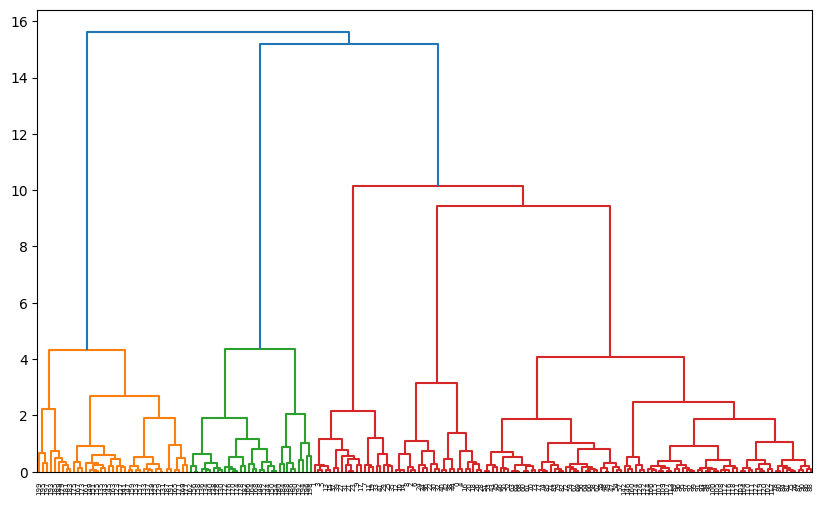

In [14]:
Z=linkage(X_scaled,method='ward')
plt.figure(figsize=(10,6))
dendrogram(Z)
plt.show()

In [15]:
model = AgglomerativeClustering(n_clusters=5)
clusters = model.fit_predict(X_scaled)

In [16]:
df['Cluster']=clusters

In [17]:
df['Cluster'].value_counts()

Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64

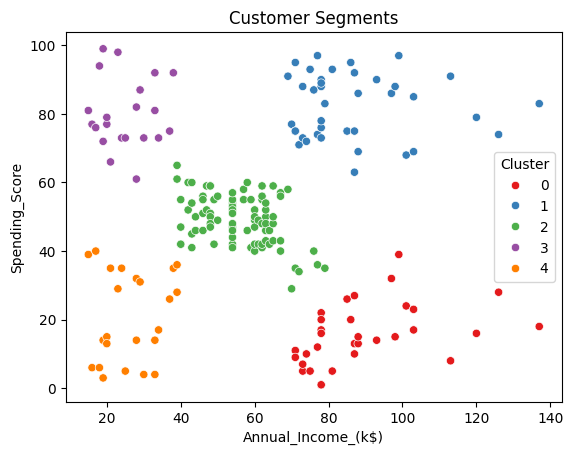

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=df['Annual_Income_(k$)'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

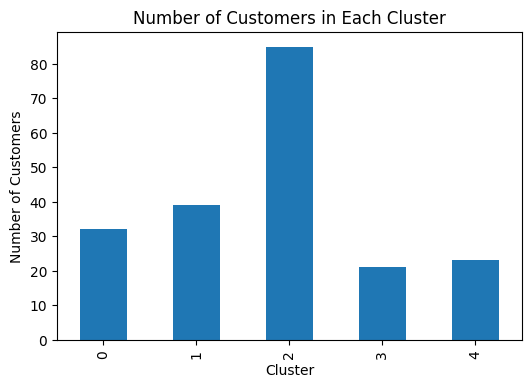

In [19]:
plt.figure(figsize=(6,4))

df['Cluster'].value_counts().sort_index().plot(kind='bar')

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

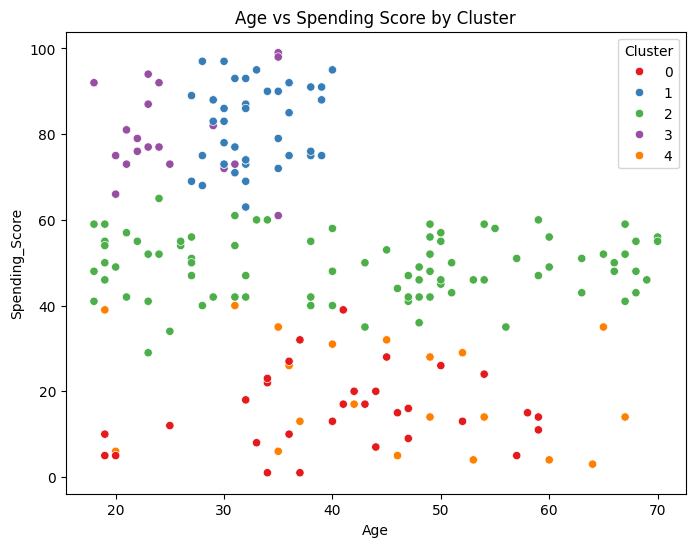

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Age'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Age vs Spending Score by Cluster")

plt.show()

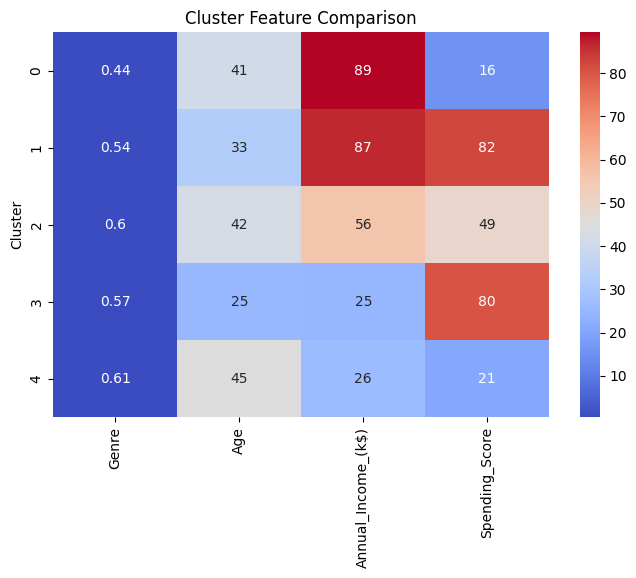

In [21]:
plt.figure(figsize=(8,5))

cluster_profile = df.groupby('Cluster').mean()

sns.heatmap(cluster_profile, annot=True, cmap='coolwarm')

plt.title("Cluster Feature Comparison")

plt.show()